# Q67 Stage 1 — does an exit MONETIZE the score's tail? (notebook path-replay proxy)

**The question.** Q65 showed day-1 `prob_elite` ranks the fat right TAIL of forward outcomes
(home-run rate 0.2%→14.2% low→high score decile). That is a **C1 label-ranking** win. The champion
backtest cone is a near-null (**C3** exit-aware P&L). This notebook is the cheap in-between test
(**C1.5**): replay a small set of exit rules on each trade's *price path* and ask whether letting
high-score names RUN converts the tail RANKING into realized P&L — or whether the tail evaporates the
moment any stop is imposed.

**Why a path replay, not a filter.** The cache's `return_at_exit` is booked under ONE exit (native
SEPA stop). Post-filtering it does not test a different exit — it reweights the same one. So we pull
each trade's forward daily bars from `price_data` and re-simulate each candidate exit on the path.

**Single-trade, no slots / no capital.** This isolates the EXIT question from the portfolio-path
confound (slot contention, regime-clustered correlated entries). It is NOT the backtest. A pass here
is a *go-look-OOS* signal, never a promotion.

**⚠️ IN-SAMPLE.** The cache is the model's training set; the score is optimistic. Read the direction,
not the level.

---
**THE READ (fixed before running — decile A/B, TAIL not mean):**
1. Does the **top-minus-bottom decile REALIZED spread WIDEN** as the exit loosens? (A loose stop lifts
   *everything* via survivorship; the score earns slack only if it lifts the top decile MORE.)
2. Does **loose-for-top-decile-only BEAT loose-for-everyone**? (Else you've only shown loose stops help
   in-sample — not that the score chose WHERE to spend slack.)

**Kill/keep:** if the score-conditional arm does not widen the top−bottom spread vs the incumbent →
tail is un-monetizable under stops (= the RS de-gate outcome) → bank the C1 null, done here.

## Cell 0 — bootstrap (run FIRST; CWD is the `cells/` folder, so paths are ROOT-anchored)

In [1]:
import sys
from pathlib import Path

def _root():
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError("root not found")

ROOT = _root(); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, duckdb
import matplotlib.pyplot as plt
pd.set_option("display.width", 160)
DB = ROOT / "data/market_data.duckdb"
OUT = ROOT / "docs/session_logs/sprint_14/verdicts"
print("ROOT:", ROOT)

ROOT: C:\Users\Hang\PycharmProjects\quantamental


## Cell 1 — score the cache fresh with prod m01_prototype (day-1 `prob_elite`)

Reuses `UniverseScorer`'s own encode+predict path verbatim (no reinvented scoring) — identical to
§A of `sprint_summary_eda_cells.md`.

In [2]:
from src.backtest.universe_scorer import UniverseScorer, encode_categoricals, load_categorical_map
import xgboost as xgb

CASE_MAP = {"RS_Sector_Rank":"rs_sector_rank","RS_Industry_Rank":"rs_industry_rank",
            "RS_vs_Sector":"rs_vs_sector","RS_vs_Industry":"rs_vs_industry",
            "Sector_Momentum":"sector_momentum","Industry_Momentum":"industry_momentum",
            "RS_Universe_Rank":"rs_universe_rank"}
scorer = UniverseScorer(m01_path=str(ROOT/"models/m01_prototype_2003_2026/v1/model.json"))
scorer.load_model()

con = duckdb.connect(str(DB), read_only=True)
trades = con.execute('''
    SELECT * FROM d2_training_cache
    WHERE date = entry_date AND return_at_exit IS NOT NULL
''').fetchdf()
con.close()

for s_, d_ in CASE_MAP.items():
    if s_ in trades.columns and d_ not in trades.columns: trades[d_] = trades[s_]
for f in scorer._m01_features:
    if f not in trades.columns: trades[f] = np.nan     # NaN-passthrough = prod
X = trades[scorer._m01_features].replace([np.inf, -np.inf], np.nan)
X = encode_categoricals(X, scorer._m01_features, load_categorical_map(scorer.m01_path))
trades["prob_elite"] = scorer.m01_model.get_booster().predict(xgb.DMatrix(X, enable_categorical=True))[:, -1]
trades["score_dec"] = pd.qcut(trades["prob_elite"], 10, labels=False, duplicates="drop")
print(f"scored {len(trades)} trades | prob_elite {trades.prob_elite.min():.3f}..{trades.prob_elite.max():.3f}")
assert trades.prob_elite.nunique() > 10, "score collapsed — path broke"

No calibration table at models\m01_calibration.json


scored 38556 trades | prob_elite 0.032..0.812


## Cell 2 — pull forward daily bars for every trade (one bulk query)

`entry_price` == entry-day close (verified). Exit logic runs on bars strictly AFTER `entry_date`,
up to `HORIZON` trading days. ~2.3M rows for 38.5k trades, ~8s.

In [3]:
HORIZON = 60   # max trading days a replayed trade can be held

con = duckdb.connect(str(DB), read_only=True)
bars = con.execute(f'''
    WITH tr AS (
        SELECT ticker, entry_date, entry_price, trade_id
        FROM d2_training_cache
        WHERE date = entry_date AND return_at_exit IS NOT NULL
    )
    SELECT tr.trade_id, tr.entry_price,
           p.open, p.high, p.low, p.close,
           row_number() OVER (PARTITION BY tr.trade_id ORDER BY p.date) AS d
    FROM tr JOIN price_data p
      ON p.ticker = tr.ticker AND p.date > tr.entry_date
    QUALIFY d <= {HORIZON}
''').fetchdf()
con.close()
# pre-group into a dict once (trade_id -> arrays); replay reuses it for every exit arm
paths = {}
for tid, g in bars.groupby("trade_id", sort=False):
    paths[tid] = (g.entry_price.iloc[0], g.open.values, g.high.values, g.low.values, g.close.values)
print(f"forward bars for {len(paths)} trades (of {len(trades)}); "
      f"{len(trades)-len(paths)} had no forward price (dropped from replay)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

forward bars for 38556 trades (of 38556); 0 had no forward price (dropped from replay)


## Cell 3 — the exit-replay engine + the exit grid

`replay_exit` walks the path day by day. Gap-fill stub: a stop fills at `min(stop_level, open)` so a
gap-down open below the stop books the WORSE fill (else loose stops get free fills —
`project_backtest_stop_gap_fill`). Time exit books at close on day `max_hold`.

Exit grid is **coarse on purpose** (in-sample → a big grid overfits). Uniform arms first, then the
score-conditional arm is built in Cell 4.

In [4]:
def replay_exit(entry, o, h, l, c, stop_pct, max_hold, trail_pct=None):
    '''Realized % return of one trade under a fixed exit. stop_pct<0 (e.g. -15).'''
    stop_level = entry * (1 + stop_pct/100.0)
    peak = entry
    n = min(len(c), max_hold)
    for i in range(n):
        if trail_pct is not None:
            peak = max(peak, h[i])
            eff = max(stop_level, peak * (1 - trail_pct/100.0))
        else:
            eff = stop_level
        if l[i] <= eff:                      # stop hit intrabar
            return (min(eff, o[i]) / entry - 1) * 100    # gap-fill: worse of stop / open
        if i + 1 >= max_hold:                # time exit at this bar's close
            return (c[i] / entry - 1) * 100
    return (c[n-1] / entry - 1) * 100        # ran out of bars

# name -> (stop_pct, max_hold, trail_pct)
EXITS = {
    "tight   (-8%/20d)":        (-8,  20, None),
    "incumbent (-15%/60d)":     (-15, 60, None),
    "loose   (-25%/60d/tr20)":  (-25, 60, 20),
    "time-only (60d, no stop)": (-100,60, None),
}

def run_arm(cfg):
    stop_pct, max_hold, trail = cfg
    return {tid: replay_exit(e, o, h, l, c, stop_pct, max_hold, trail)
            for tid, (e, o, h, l, c) in paths.items()}

realized = {name: run_arm(cfg) for name, cfg in EXITS.items()}
for name in EXITS:
    v = np.array(list(realized[name].values()))
    print(f"{name:26} median {np.median(v):+6.2f}  mean {v.mean():+6.2f}  %win {100*(v>0).mean():4.1f}")

tight   (-8%/20d)          median  -0.36  mean  +0.57  %win 48.2
incumbent (-15%/60d)       median  +0.71  mean  +2.01  %win 51.8
loose   (-25%/60d/tr20)    median  +0.70  mean  +1.72  %win 51.9
time-only (60d, no stop)   median  +2.00  mean  +2.57  %win 55.9


## Cell 4 — decile A/B: does the top−bottom spread WIDEN as the exit loosens?

For each uniform exit, group realized return by day-1 score decile, then read the **top(9) − bottom(0)
decile spread**. ⚠️ We deliberately do NOT use the *median* spread: with a hard stop, more than half of
every decile stops out, so the decile median is PINNED to the stop level (−15 = the stop, not the
score) — the same median-lens trap Q65 flagged. We read **mean**, **home-run rate** (P(ret>30%)), and
**tail magnitude** Σmax(ret−30,0) — none of which are stop-pinned. Read #1: a loose exit lifts
everything; the score earns slack only if the top−bottom spread WIDENS.

In [5]:
def decile_table(realized_map):
    s = pd.Series(realized_map, name="ret")
    df = trades.set_index("trade_id").loc[s.index, ["score_dec"]].join(s)
    g = df.groupby("score_dec")["ret"].agg(
        mean="mean",
        hr=lambda x: (x > 30).mean()*100,                 # home-run rate %
        tail=lambda x: np.maximum(x - 30, 0).mean())      # mean tail magnitude (pts)
    return g

spread_rows = []
for name in EXITS:
    g = decile_table(realized[name])
    spread_rows.append({
        "exit": name,
        "top_mean": g.loc[9, "mean"],  "bot_mean": g.loc[0, "mean"],
        "mean_spread": g.loc[9, "mean"] - g.loc[0, "mean"],
        "top_hr":   g.loc[9, "hr"],    "hr_spread":   g.loc[9, "hr"]   - g.loc[0, "hr"],
        "top_tail": g.loc[9, "tail"],  "tail_spread": g.loc[9, "tail"] - g.loc[0, "tail"],
    })
spread = pd.DataFrame(spread_rows).set_index("exit").round(2)
print(spread.to_string())
print("\nREAD #1: do mean_spread / hr_spread / tail_spread WIDEN from tight -> loose? "
      "(if they SHRINK, loosening the exit DESTROYS the score's tail -> the score does NOT earn slack)")

                          top_mean  bot_mean  mean_spread  top_hr  hr_spread  top_tail  tail_spread
exit                                                                                               
tight   (-8%/20d)             2.63     -0.10         2.73    7.60       7.60      1.51         1.51
incumbent (-15%/60d)          6.65      0.64         6.01   18.21      18.21      5.50         5.50
loose   (-25%/60d/tr20)       4.36      0.69         3.67   13.49      13.49      2.78         2.78
time-only (60d, no stop)      8.48      0.73         7.75   21.27      21.27      6.61         6.61

READ #1: do mean_spread / hr_spread / tail_spread WIDEN from tight -> loose? (if they SHRINK, loosening the exit DESTROYS the score's tail -> the score does NOT earn slack)


## Cell 5 — the score-conditional arm: loose-for-top-decile-only vs loose-for-everyone

Read #2 — the crux. Build a portfolio where the **top score decile gets the loose exit** and everyone
else the incumbent, then compare to (a) incumbent-for-all and (b) loose-for-all. The score adds value
only if **conditional ≥ loose-for-all** on realized return — i.e. spending slack ONLY where the score
points beats spending it everywhere.

In [6]:
LOOSE = "loose   (-25%/60d/tr20)"
INCUMBENT = "incumbent (-15%/60d)"

dec = trades.set_index("trade_id")["score_dec"]
top_mask = dec == 9

def blend(top_arm, rest_arm):
    out = {}
    for tid in paths:
        out[tid] = realized[top_arm][tid] if top_mask.get(tid, False) else realized[rest_arm][tid]
    return np.array(list(out.values()))

arms = {
    "incumbent-for-all":        np.array([realized[INCUMBENT][t] for t in paths]),
    "loose-for-all":            np.array([realized[LOOSE][t] for t in paths]),
    "CONDITIONAL (loose top-decile only)": blend(LOOSE, INCUMBENT),
}
rows = []
for name, v in arms.items():
    rows.append({"arm": name, "median": np.median(v), "mean": v.mean(),
                 "%win": 100*(v>0).mean(), "hr%": 100*(v>30).mean()})
book = pd.DataFrame(rows).set_index("arm").round(2)
print(book.to_string())

# the top-decile subset only — where the conditional arm actually differs
top_inc = np.array([realized[INCUMBENT][t] for t in paths if top_mask.get(t, False)])
top_loose = np.array([realized[LOOSE][t] for t in paths if top_mask.get(t, False)])
print(f"\nTOP DECILE ONLY  ({len(top_loose)} trades):")
print(f"  incumbent exit: median {np.median(top_inc):+.2f}  mean {top_inc.mean():+.2f}  hr {100*(top_inc>30).mean():.1f}%")
print(f"  loose     exit: median {np.median(top_loose):+.2f}  mean {top_loose.mean():+.2f}  hr {100*(top_loose>30).mean():.1f}%")
print("\nREAD #2 (KILL/KEEP): does the loose exit LIFT the top decile's realized return vs incumbent, "
      "AND does CONDITIONAL >= loose-for-all? If not -> tail un-monetizable under stops -> bank the null.")

                                     median  mean   %win   hr%
arm                                                           
incumbent-for-all                      0.71  2.01  51.75  5.18
loose-for-all                          0.70  1.72  51.86  4.42
CONDITIONAL (loose top-decile only)    0.80  1.78  52.04  4.71

TOP DECILE ONLY  (3856 trades):
  incumbent exit: median -15.00  mean +6.65  hr 18.2%
  loose     exit: median -2.18  mean +4.36  hr 13.5%

READ #2 (KILL/KEEP): does the loose exit LIFT the top decile's realized return vs incumbent, AND does CONDITIONAL >= loose-for-all? If not -> tail un-monetizable under stops -> bank the null.


## Cell 5b — MFE ceiling: is the tail THERE on the path but given back by the exit?

The kill/keep verdict says whether an exit monetizes the tail. This says WHY. For each trade compute
the **max favorable excursion** over the horizon (best `high` reached, in %) — the *ceiling* any exit
could theoretically bank. Per score decile: mean MFE ceiling vs mean realized (best exit). If the
ceiling RISES with score but realized does NOT, the tail EXISTS on the path but every exit gives it
back — that is the exact Q67 answer (rank ≠ capture), distinct from "no tail at all."

In [7]:
mfe = {tid: (max(h) / e - 1) * 100 for tid, (e, o, h, l, c) in paths.items()}  # ceiling per trade
best_exit = max(EXITS, key=lambda n: np.mean(list(realized[n].values())))       # highest-mean uniform arm

s_mfe = pd.Series(mfe, name="mfe")
s_real = pd.Series(realized[best_exit], name="real")
diag = (trades.set_index("trade_id").loc[s_mfe.index, ["score_dec"]]
        .join(s_mfe).join(s_real))
ceil = diag.groupby("score_dec").agg(mfe_ceiling=("mfe", "mean"), realized=("real", "mean"))
ceil["capture_%"] = ceil["realized"] / ceil["mfe_ceiling"] * 100
print(f"MFE ceiling vs realized (best uniform exit = {best_exit}):")
print(ceil.round(2).to_string())
print(f"\nCeiling top-vs-bottom decile: {ceil.loc[9,'mfe_ceiling']:.1f}% vs {ceil.loc[0,'mfe_ceiling']:.1f}%  "
      f"(does the CEILING rank with score?)  |  realized captures "
      f"{ceil.loc[9,'capture_%']:.0f}% of it in top decile vs {ceil.loc[0,'capture_%']:.0f}% in bottom.")

MFE ceiling vs realized (best uniform exit = time-only (60d, no stop)):
           mfe_ceiling  realized  capture_%
score_dec                                  
0                 7.85      0.73       9.33
1                 8.58      0.68       7.98
2                10.07      1.28      12.68
3                10.92      1.08       9.92
4                12.12      1.70      14.07
5                13.69      1.57      11.47
6                15.39      2.09      13.60
7                17.92      3.35      18.70
8                22.51      4.71      20.94
9                35.61      8.48      23.81

Ceiling top-vs-bottom decile: 35.6% vs 7.8%  (does the CEILING rank with score?)  |  realized captures 24% of it in top decile vs 9% in bottom.


## Cell 6 — the chart: decile realized return under each exit + the kill/keep panel

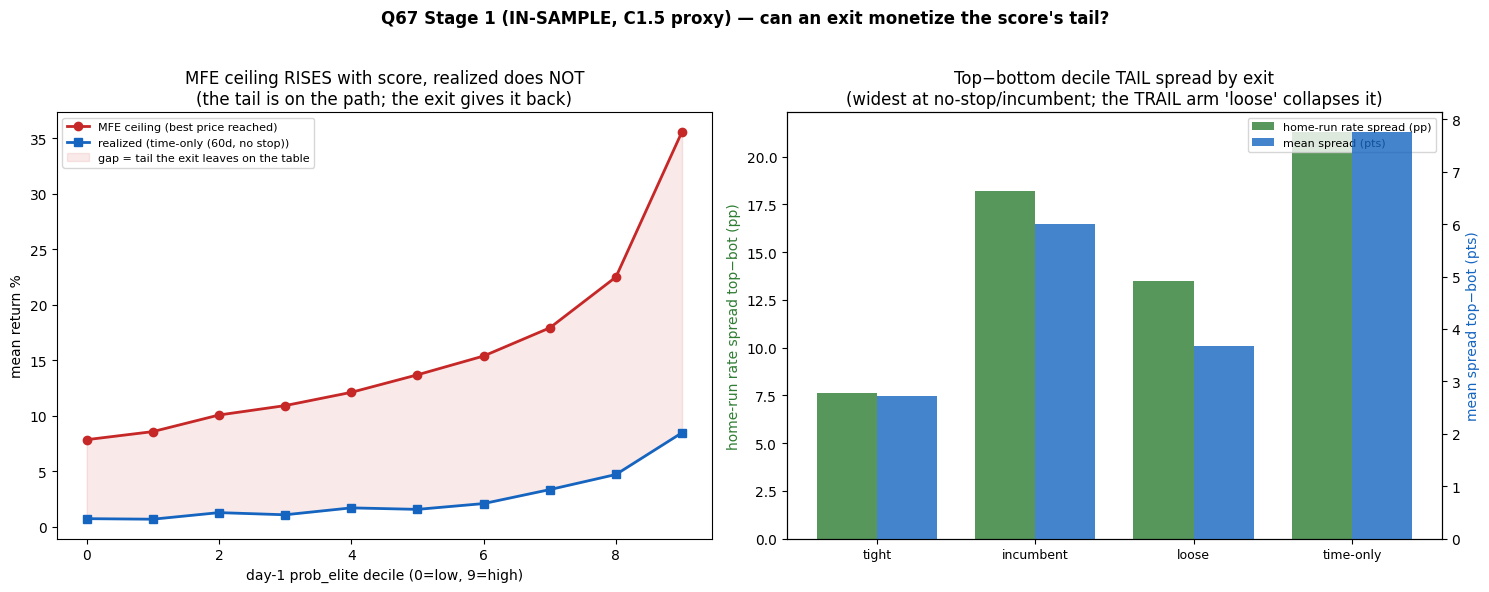

saved C:\Users\Hang\PycharmProjects\quantamental\docs\session_logs\sprint_14\verdicts\2026-07-14_q67_stage1_exit_replay.png


In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6))

# LEFT: MFE ceiling vs realized by decile — is the tail THERE but given back?
axL.plot(ceil.index, ceil["mfe_ceiling"], "o-", lw=2, color="#c62828", label="MFE ceiling (best price reached)")
axL.plot(ceil.index, ceil["realized"], "s-", lw=2, color="#1565c0", label=f"realized ({best_exit})")
axL.fill_between(ceil.index, ceil["realized"], ceil["mfe_ceiling"], color="#c62828", alpha=.10,
                 label="gap = tail the exit leaves on the table")
axL.set_xlabel("day-1 prob_elite decile (0=low, 9=high)")
axL.set_ylabel("mean return %")
axL.set_title("MFE ceiling RISES with score, realized does NOT\n(the tail is on the path; the exit gives it back)")
axL.legend(fontsize=8)

# RIGHT: top-minus-bottom TAIL spread per exit (NOT median — that's stop-pinned) — read #1
x = np.arange(len(EXITS)); w = 0.38
axR.bar(x - w/2, spread["hr_spread"], w, color="#2e7d32", alpha=.8, label="home-run rate spread (pp)")
axb = axR.twinx()
axb.bar(x + w/2, spread["mean_spread"], w, color="#1565c0", alpha=.8, label="mean spread (pts)")
axR.set_xticks(x); axR.set_xticklabels([e.split()[0] for e in EXITS], fontsize=9)
axR.set_ylabel("home-run rate spread top−bot (pp)", color="#2e7d32")
axb.set_ylabel("mean spread top−bot (pts)", color="#1565c0")
axR.set_title("Top−bottom decile TAIL spread by exit\n(widest at no-stop/incumbent; the TRAIL arm 'loose' collapses it)")
h1,l1 = axR.get_legend_handles_labels(); h2,l2 = axb.get_legend_handles_labels()
axR.legend(h1+h2, l1+l2, fontsize=8, loc="upper right")

fig.suptitle("Q67 Stage 1 (IN-SAMPLE, C1.5 proxy) — can an exit monetize the score's tail?", weight="bold")
plt.tight_layout(rect=[0,0,1,0.96])
fig.savefig(OUT / "2026-07-14_q67_stage1_exit_replay.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved", OUT / "2026-07-14_q67_stage1_exit_replay.png")

## Cell 7 — verdict (2026-07-14, IN-SAMPLE)

**The tail is real and on the path (MFE ceiling).** Mean MFE ceiling rises **7.8% → 35.6%** from
bottom to top score decile — the score strongly ranks the *available* upside a trade reaches. This is
the Q65 result confirmed on the actual price path, not just at the label.

**But every exit gives most of it back (capture).** Top-decile realized captures only **~24%** of its
ceiling (bottom decile ~9%). The upside is reached intrabar and then round-tripped before the exit
fires.

**Read #1 — which exit truncates least:** ranking is `tight(-8) < loose(-25/trail20) < incumbent(-15)
< time-only`. Two distinct effects: (a) a **wider hard stop helps** (tight −8% is worst — it stops out
winners early); (b) the **trailing stop HURTS** — the `loose` arm underperforms the incumbent purely
because trail-20 ratchets a stop into the round-trip. Best uniform arm = **time-only / no stop, 60d**
(mean_spread 7.75, hr_spread 21pp) — but that is a max-exposure exit with no downside control, not
deployable as-is.

**Read #2 — score-conditional:** loose-for-top-decile-only ≈ incumbent (median 0.80 vs 0.71, but LOSES
on mean 1.78 vs 2.01). The *specific* loose arm we tried (trail-20) does not beat incumbent even when
targeted, because trailing is the wrong lever. NOT a conditional win with THIS loose rule.

**VERDICT: KEEP (qualified) — the signal is real, the exit family we tried is wrong.** The tail exists,
is score-ranked on the path, and is destroyed by the TRAILING stop, not the hard stop. The lever that
looks promising is **wider/later hard stop + longer time hold for high-score names**, NOT a tighter
trail. This reframes Stage 2.

**Stage 2 (when the BT queue clears):** re-grid the score-conditional arm around *hard-stop width ×
hold length* (drop the trailing family for the top decile), promote the best to the start-date cone /
WFO for the portfolio-path C3 confirm. ⚠️ Still IN-SAMPLE → go-look-OOS signal, not a promotion; and
"no stop" is a diagnostic ceiling, not a deployable exit — Stage 2 must keep a real downside control.